# Pipeline information flow

How data moves from the outside APIs, through the scripts and notebooks, into the report files, and out to the
dashboard and the **Alpaca LIVE (real-money)** trader.

This notebook only draws: it imports matplotlib and nothing from the pipeline, so running it is always safe.

Colors: orange = outside data source · blue = script / notebook step · pale green = file in `Reports/` ·
purple = display only · red = places real orders · yellow = scheduler.

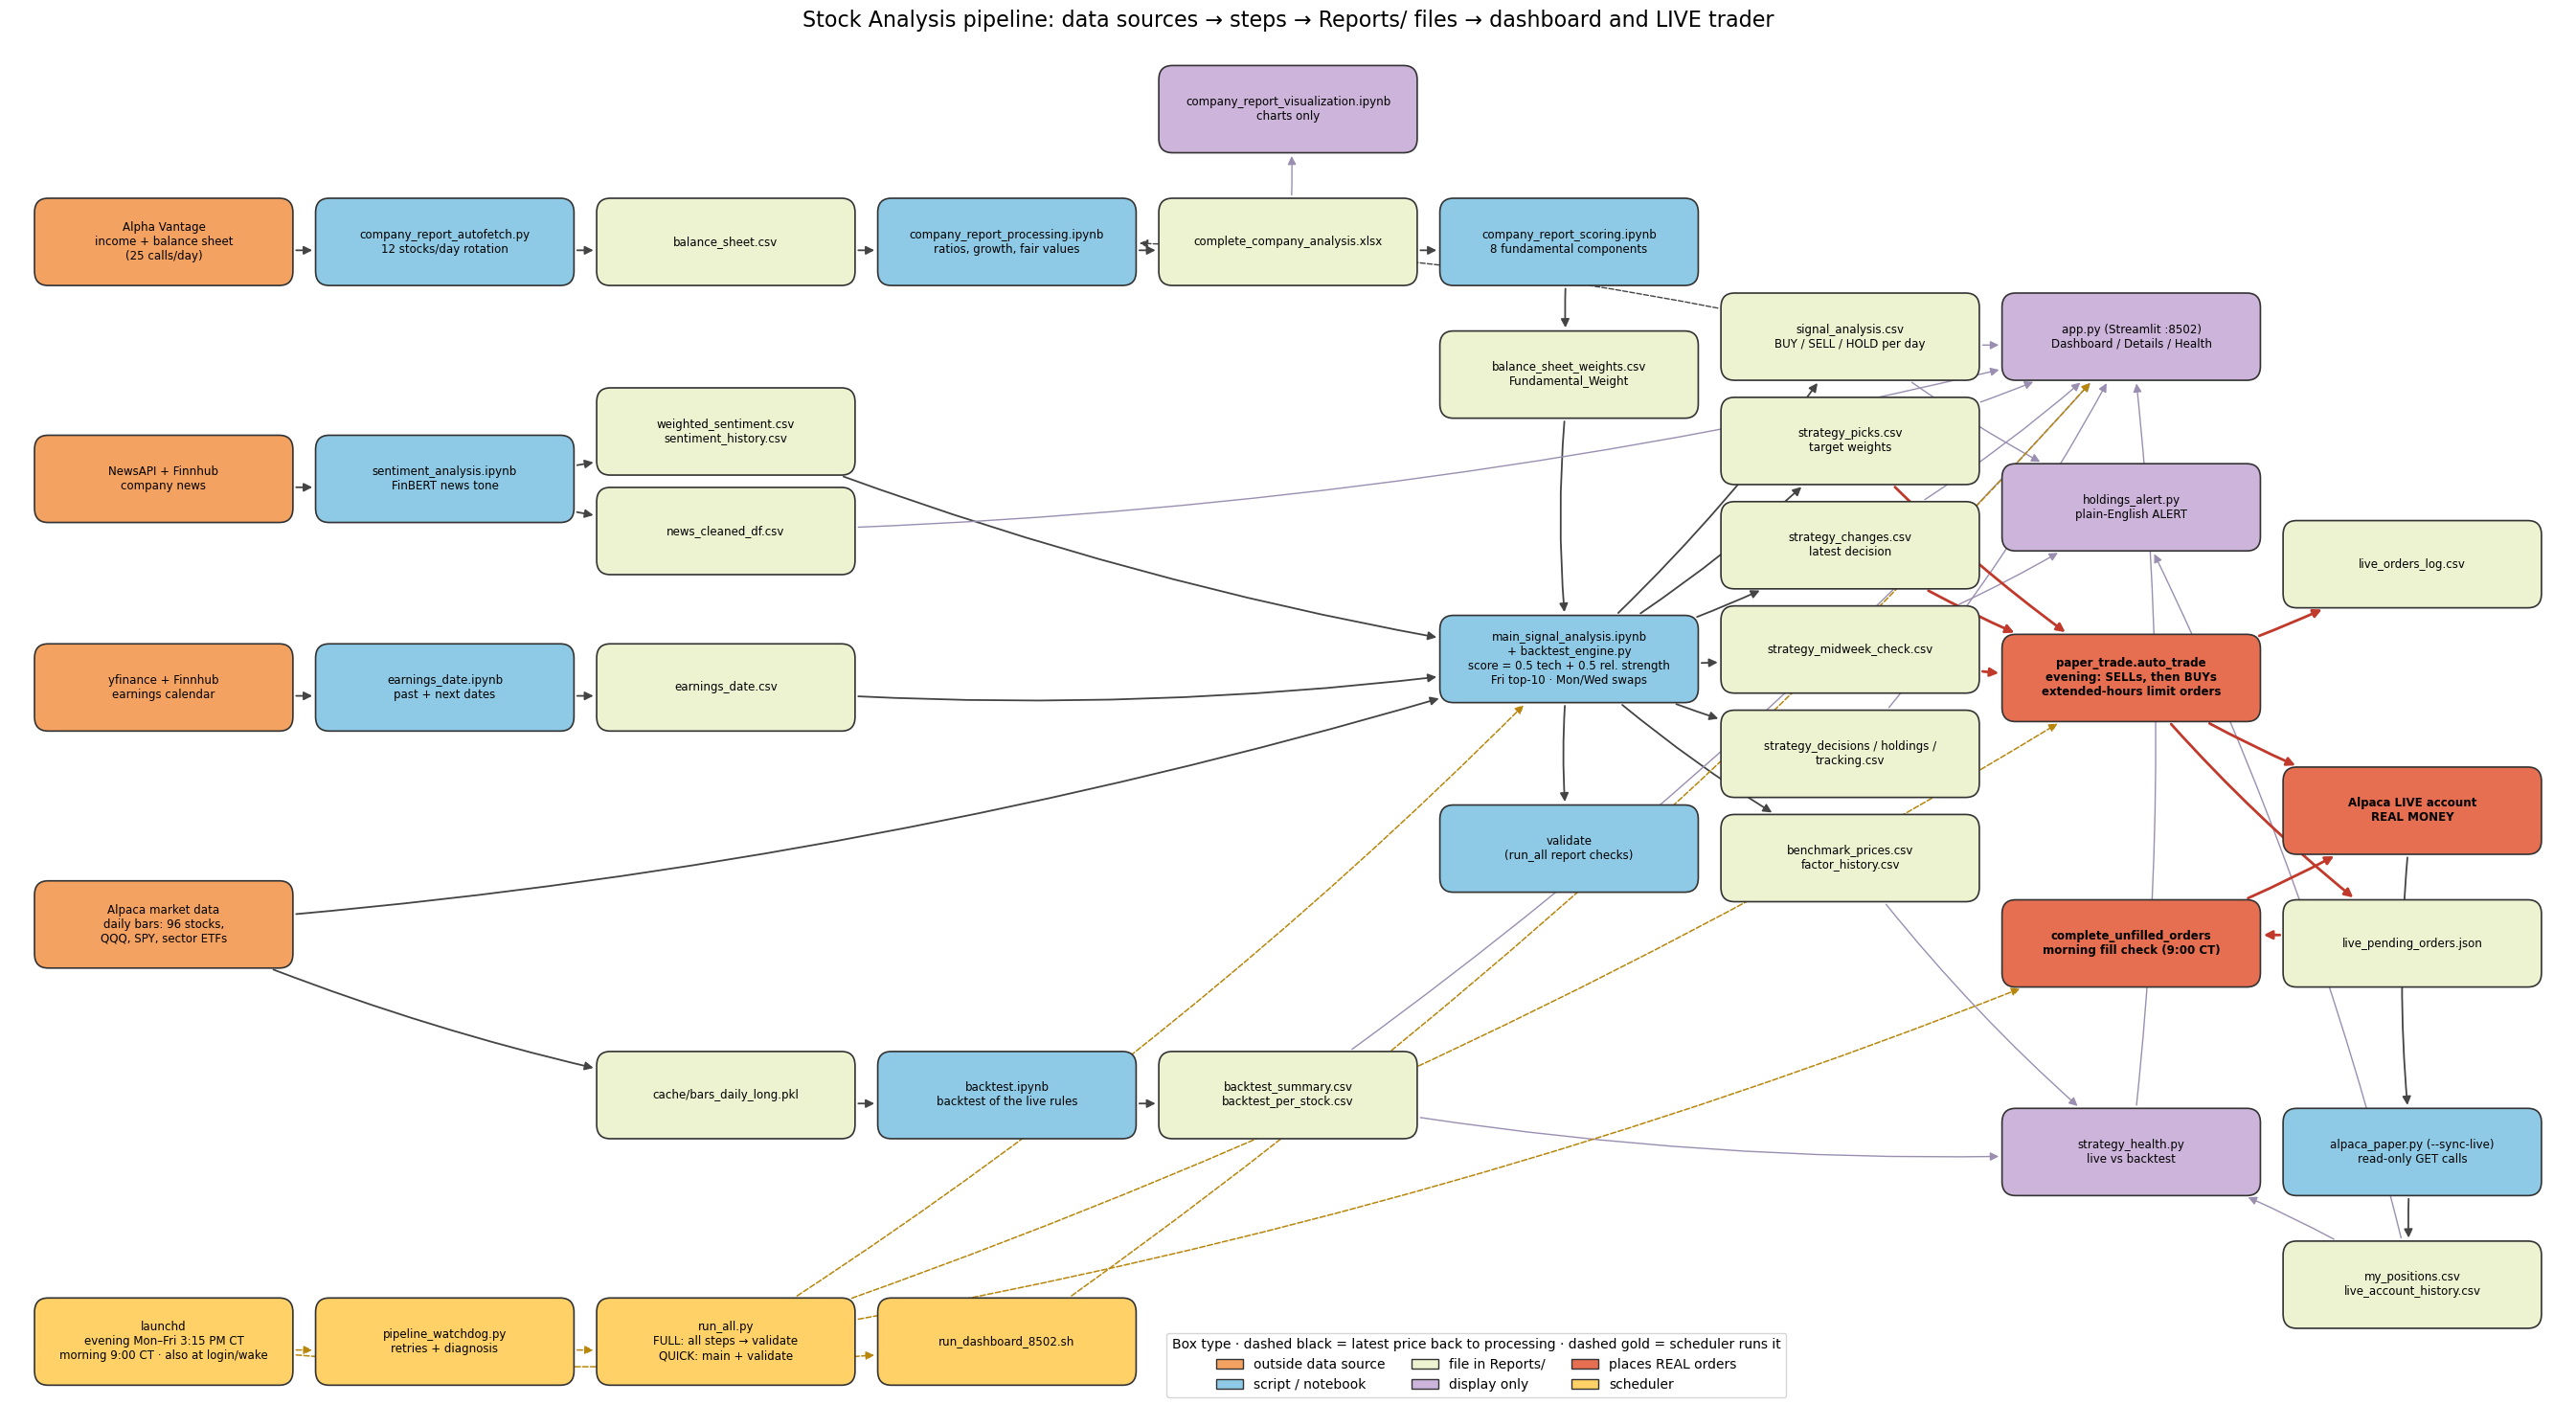

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch

COLORS = {"source": "#F4A261", "step": "#8ECAE6", "file": "#EDF2D0", "view": "#CDB4DB",
          "live": "#E76F51", "schedule": "#FFD166"}
LEGEND = {"source": "outside data source", "step": "script / notebook", "file": "file in Reports/",
          "view": "display only", "live": "places REAL orders", "schedule": "scheduler"}
W, H, DX = 2.75, 0.82, 3.1  # box width/height, column spacing

# key: (column, y, kind, label)
NODES = {
    "av":        (0, 13.0, "source", "Alpha Vantage\nincome + balance sheet\n(25 calls/day)"),
    "news":      (0, 10.5, "source", "NewsAPI + Finnhub\ncompany news"),
    "cal":       (0, 8.3, "source", "yfinance + Finnhub\nearnings calendar"),
    "bars":      (0, 5.8, "source", "Alpaca market data\ndaily bars: 96 stocks,\nQQQ, SPY, sector ETFs"),
    "autofetch": (1, 13.0, "step", "company_report_autofetch.py\n12 stocks/day rotation"),
    "sentiment": (1, 10.5, "step", "sentiment_analysis.ipynb\nFinBERT news tone"),
    "earnings":  (1, 8.3, "step", "earnings_date.ipynb\npast + next dates"),
    "bs":        (2, 13.0, "file", "balance_sheet.csv"),
    "ws":        (2, 11.0, "file", "weighted_sentiment.csv\nsentiment_history.csv"),
    "nc":        (2, 9.95, "file", "news_cleaned_df.csv"),
    "ed":        (2, 8.3, "file", "earnings_date.csv"),
    "pkl":       (2, 4.0, "file", "cache/bars_daily_long.pkl"),
    "proc":      (3, 13.0, "step", "company_report_processing.ipynb\nratios, growth, fair values"),
    "bt":        (3, 4.0, "step", "backtest.ipynb\nbacktest of the live rules"),
    "xlsx":      (4, 13.0, "file", "complete_company_analysis.xlsx"),
    "viz":       (4, 14.4, "view", "company_report_visualization.ipynb\ncharts only"),
    "btout":     (4, 4.0, "file", "backtest_summary.csv\nbacktest_per_stock.csv"),
    "score":     (5, 13.0, "step", "company_report_scoring.ipynb\n8 fundamental components"),
    "bw":        (5, 11.6, "file", "balance_sheet_weights.csv\nFundamental_Weight"),
    "main":      (5, 8.6, "step", "main_signal_analysis.ipynb\n+ backtest_engine.py\nscore = 0.5 tech + 0.5 rel. strength\nFri top-10 · Mon/Wed swaps"),
    "val":       (5, 6.6, "step", "validate\n(run_all report checks)"),
    "sig":       (6, 12.0, "file", "signal_analysis.csv\nBUY / SELL / HOLD per day"),
    "picks":     (6, 10.9, "file", "strategy_picks.csv\ntarget weights"),
    "changes":   (6, 9.8, "file", "strategy_changes.csv\nlatest decision"),
    "mw":        (6, 8.7, "file", "strategy_midweek_check.csv"),
    "hist":      (6, 7.6, "file", "strategy_decisions / holdings /\ntracking.csv"),
    "bench":     (6, 6.5, "file", "benchmark_prices.csv\nfactor_history.csv"),
    "app":       (7, 12.0, "view", "app.py (Streamlit :8502)\nDashboard / Details / Health"),
    "alert":     (7, 10.2, "view", "holdings_alert.py\nplain-English ALERT"),
    "trade":     (7, 8.4, "live", "paper_trade.auto_trade\nevening: SELLs, then BUYs\nextended-hours limit orders"),
    "fill":      (7, 5.6, "live", "complete_unfilled_orders\nmorning fill check (9:00 CT)"),
    "health":    (7, 3.4, "view", "strategy_health.py\nlive vs backtest"),
    "olog":      (8, 9.6, "file", "live_orders_log.csv"),
    "live":      (8, 7.0, "live", "Alpaca LIVE account\nREAL MONEY"),
    "pend":      (8, 5.6, "file", "live_pending_orders.json"),
    "sync":      (8, 3.4, "step", "alpaca_paper.py (--sync-live)\nread-only GET calls"),
    "pos":       (8, 2.0, "file", "my_positions.csv\nlive_account_history.csv"),
    "launchd":   (0, 1.4, "schedule", "launchd\nevening Mon–Fri 3:15 PM CT\nmorning 9:00 CT · also at login/wake"),
    "wd":        (1, 1.4, "schedule", "pipeline_watchdog.py\nretries + diagnosis"),
    "runall":    (2, 1.4, "schedule", "run_all.py\nFULL: all steps → validate\nQUICK: main + validate"),
    "dash":      (3, 1.4, "schedule", "run_dashboard_8502.sh"),
}

# (from, to, edge type): data = normal flow, live = real-money path, display = feeds the dashboard, run = scheduler runs it
EDGES = [
    ("av", "autofetch", "data"), ("autofetch", "bs", "data"), ("bs", "proc", "data"), ("proc", "xlsx", "data"),
    ("xlsx", "score", "data"), ("xlsx", "viz", "display"), ("score", "bw", "data"), ("bw", "main", "data"),
    ("news", "sentiment", "data"), ("sentiment", "ws", "data"), ("sentiment", "nc", "data"), ("ws", "main", "data"),
    ("cal", "earnings", "data"), ("earnings", "ed", "data"), ("ed", "main", "data"),
    ("bars", "main", "data"), ("bars", "pkl", "data"), ("pkl", "bt", "data"), ("bt", "btout", "data"),
    ("main", "sig", "data"), ("main", "picks", "data"), ("main", "changes", "data"), ("main", "mw", "data"),
    ("main", "hist", "data"), ("main", "bench", "data"), ("main", "val", "data"),
    ("sig", "proc", "back"),
    ("sig", "app", "display"), ("picks", "app", "display"), ("changes", "app", "display"), ("hist", "app", "display"),
    ("nc", "app", "display"), ("btout", "app", "display"), ("btout", "health", "display"), ("bench", "health", "display"),
    ("sig", "alert", "display"), ("mw", "alert", "display"), ("pos", "alert", "display"), ("pos", "health", "display"),
    ("health", "app", "display"),
    ("picks", "trade", "live"), ("changes", "trade", "live"), ("mw", "trade", "live"),
    ("trade", "live", "live"), ("trade", "olog", "live"), ("trade", "pend", "live"), ("pend", "fill", "live"),
    ("fill", "live", "live"), ("live", "sync", "data"), ("sync", "pos", "data"),
    ("launchd", "wd", "run"), ("wd", "runall", "run"), ("launchd", "dash", "run"), ("dash", "app", "run"),
    ("runall", "main", "run"), ("runall", "trade", "run"), ("runall", "fill", "run"),
]
EDGE_STYLE = {"data": ("#444444", "solid", 1.3), "live": ("#C0392B", "solid", 2.0),
              "display": ("#9A8FB0", "solid", 1.0), "back": ("#444444", "dashed", 1.0), "run": ("#B8860B", "dashed", 1.1)}

fig, ax = plt.subplots(figsize=(27, 15))
boxes = {}
for key, (col, y, kind, label) in NODES.items():
    box = FancyBboxPatch((col * DX - W / 2, y - H / 2), W, H, boxstyle="round,pad=0.05,rounding_size=0.15",
                         fc=COLORS[kind], ec="#333333", lw=1.2, zorder=2)
    ax.add_patch(box)
    ax.text(col * DX, y, label, ha="center", va="center", fontsize=8.5, zorder=3,
            fontweight="bold" if kind == "live" else "normal")
    boxes[key] = box
for a, b, kind in EDGES:
    color, ls, lw = EDGE_STYLE[kind]
    ax.add_patch(FancyArrowPatch((NODES[a][0] * DX, NODES[a][1]), (NODES[b][0] * DX, NODES[b][1]),
                                 patchA=boxes[a], patchB=boxes[b], arrowstyle="-|>", mutation_scale=13,
                                 color=color, linestyle=ls, lw=lw, connectionstyle="arc3,rad=0.06", zorder=1))
ax.legend(handles=[Patch(fc=COLORS[k], ec="#333333", label=v) for k, v in LEGEND.items()],
          loc="lower left", bbox_to_anchor=(0.45, 0.01), ncol=3, fontsize=10, frameon=True,
          title="Box type · dashed black = latest price back to processing · dashed gold = scheduler runs it")
ax.set_xlim(-1.7, 8 * DX + 1.7)
ax.set_ylim(0.6, 15.1)
ax.axis("off")
ax.set_title("Stock Analysis pipeline: data sources → steps → Reports/ files → dashboard and LIVE trader",
             fontsize=16, pad=12)
plt.tight_layout()
plt.show()

## Same flow as text (Mermaid)

```mermaid
flowchart LR
  AV[Alpha Vantage] --> AF[company_report_autofetch.py] --> BS[(balance_sheet.csv)]
  BS --> PR[company_report_processing.ipynb] --> XL[(complete_company_analysis.xlsx)]
  XL --> SC[company_report_scoring.ipynb] --> BW[(balance_sheet_weights.csv)]
  XL --> VZ[company_report_visualization.ipynb]
  NEWS[NewsAPI + Finnhub] --> SE[sentiment_analysis.ipynb] --> WS[(weighted_sentiment.csv)]
  SE --> NC[(news_cleaned_df.csv)]
  CAL[yfinance + Finnhub] --> ED[earnings_date.ipynb] --> EDC[(earnings_date.csv)]
  BARS[Alpaca market data] --> MAIN[main_signal_analysis.ipynb + backtest_engine.py]
  BW --> MAIN
  WS --> MAIN
  EDC --> MAIN
  MAIN --> SIG[(signal_analysis.csv)]
  MAIN --> PICKS[(strategy_picks.csv)]
  MAIN --> CH[(strategy_changes.csv)]
  MAIN --> MW[(strategy_midweek_check.csv)]
  MAIN --> HIST[(decisions / holdings / tracking / benchmark csv)]
  SIG -. latest price .-> PR
  BARS --> PKL[(bars_daily_long.pkl)] --> BT[backtest.ipynb] --> BTO[(backtest_summary / per_stock csv)]
  SIG & PICKS & CH & HIST & NC & BTO --> APP[app.py Streamlit :8502]
  PICKS & CH & MW --> TRADE[paper_trade.auto_trade - REAL MONEY]
  TRADE --> LIVE[Alpaca LIVE account]
  TRADE --> PEND[(live_pending_orders.json)] --> FILL[morning fill check] --> LIVE
  TRADE --> OLOG[(live_orders_log.csv)]
  LIVE --> SYNC[alpaca_paper.py sync] --> POS[(my_positions.csv, live_account_history.csv)]
  POS --> ALERT[holdings_alert.py]
  POS --> HEALTH[strategy_health.py] --> APP
  LAUNCHD[launchd] --> WD[pipeline_watchdog.py] --> RUN[run_all.py]
  RUN -. runs steps .-> MAIN
  RUN -. --trade .-> TRADE
  RUN -. --fill-check .-> FILL
```

## When each part runs

| Trigger | Command | What happens |
|---|---|---|
| Mon–Fri 3:15 PM CT, at login, on wake and every 30 min (launchd `evening`) | `pipeline_watchdog.py --trade --scheduled` | Each decision (Fri rebalance, Mon/Wed check; shifted for holidays) exactly once: at 3:15 PM on its day FULL run autofetch → processing → scoring → sentiment → earnings → main → validate, then `auto_trade` (LIVE, extended hours); if missed, at the next regular session (market orders) until the next decision slot, then superseded. Otherwise one `idle:` line |
| Mon–Fri 9:00 AM CT, at login, on wake and every 30 min (launchd `morning`) | `pipeline_watchdog.py --fill-check --scheduled` | Sends the orders in `live_pending_orders.json` as market orders in regular hours (LIVE): the evening's rest from the next morning, a catch-up's at once; dropped (alert) at the next decision slot |
| Always on (launchd `dashboard-8502`) | `run_dashboard_8502.sh` | Streamlit dashboard `app.py` on port 8502 |
| Any other `python run_all.py` | QUICK mode | main + validate only (Alpaca bars, no quota APIs) |
| Manual | `python run_all.py --backtests` | Re-runs `backtest.ipynb` |

## Who writes and who reads each file

| File | Written by | Read by |
|---|---|---|
| `balance_sheet.csv` | company_report_autofetch.py | company_report_processing, app |
| `complete_company_analysis.xlsx` | company_report_processing | company_report_scoring, company_report_visualization, app |
| `balance_sheet_weights.csv` | company_report_scoring | main_signal_analysis (display columns), app |
| `weighted_sentiment.csv` | sentiment_analysis | main_signal_analysis (display columns), app |
| `news_cleaned_df.csv` | sentiment_analysis | app (news + AI summaries) |
| `earnings_date.csv` | earnings_date | main_signal_analysis (earnings rule), backtest, app |
| `signal_analysis.csv` | main_signal_analysis | app, paper_trade, holdings_alert, company_report_processing (price) |
| `strategy_picks.csv` | main_signal_analysis | paper_trade (order sizes), app |
| `strategy_changes.csv` | main_signal_analysis | paper_trade (freshness + add/hold/drop), app |
| `strategy_midweek_check.csv` | main_signal_analysis | paper_trade (mid-week swaps), holdings_alert, app |
| `strategy_decisions/holdings/tracking.csv`, `benchmark_prices.csv` | main_signal_analysis | app, strategy_health |
| `backtest_summary.csv`, `backtest_per_stock.csv` | backtest | app, strategy_health |
| `live_pending_orders.json` | paper_trade evening trade (LIVE) | morning fill check |
| `live_orders_log.csv` | paper_trade evening + morning (LIVE) | you (audit log) |
| `my_positions.csv`, `live_account_history.csv` | alpaca_paper (read-only sync) | holdings_alert, strategy_health |